In [11]:
import pandas as pd
import numpy as np

# 1. Load the datasets
# Use the file names from your directory
fg_df = pd.read_csv(r'fear_greed_index.csv')
trade_df = pd.read_csv(r'historical_data.csv')

# --- DOCUMENTATION & INSPECTION ---
print("--- Data Inspection ---")
print(f"Fear/Greed Dataset: {fg_df.shape[0]} rows, {fg_df.shape[1]} columns")
print(f"Trade Dataset: {trade_df.shape[0]} rows, {trade_df.shape[1]} columns")

# Remove duplicates
fg_df = fg_df.drop_duplicates()
trade_df = trade_df.drop_duplicates()

# --- DATETIME CONVERSION & ALIGNMENT ---

# Convert Fear/Greed date to datetime64[ns] and normalize to midnight
fg_df['date'] = pd.to_datetime(fg_df['date']).dt.normalize()

# Convert Trade timestamp to datetime64[ns] and normalize to midnight
# 'dayfirst=True' is important for your specific format
trade_df['datetime'] = pd.to_datetime(trade_df['Timestamp IST'], dayfirst=True)
trade_df['date'] = trade_df['datetime'].dt.normalize()

# Merge datasets on the date column
# This now works because both are datetime64[ns]
df = pd.merge(trade_df, fg_df[['date', 'classification', 'value']], on='date', how='inner')

# --- FEATURE ENGINEERING (METRICS) ---

# Define if a trade was a win (Profit > 0)
df['is_win'] = df['Closed PnL'] > 0

# Create daily aggregated metrics per account
daily_metrics = df.groupby(['date', 'classification', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    trade_count=('Order ID', 'count')
).reset_index()

# Calculate Long/Short Ratio per day
# This aggregates all trades for the day regardless of account
side_counts = df.groupby(['date', 'Side']).size().unstack(fill_value=0)
# Create ratio: Buy / Sell (using 1 to avoid division by zero)
side_counts['long_short_ratio'] = side_counts.get('BUY', 0) / side_counts.get('SELL', 1)

# Merge the ratio back into the main daily_metrics dataframe
daily_metrics = daily_metrics.merge(side_counts[['long_short_ratio']], on='date')

print("\n--- Processed Data Preview ---")
print(daily_metrics.head())

--- Data Inspection ---
Fear/Greed Dataset: 2644 rows, 4 columns
Trade Dataset: 211224 rows, 16 columns

--- Processed Data Preview ---
        date classification                                     Account  \
0 2023-05-01          Greed  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   
1 2023-12-05  Extreme Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   
2 2023-12-14          Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   
3 2023-12-15          Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   
4 2023-12-16          Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   

    daily_pnl  win_rate  avg_trade_size  trade_count  long_short_ratio  
0    0.000000  0.000000      159.000000            3               inf  
1    0.000000  0.000000     5556.203333            9          3.500000  
2 -205.434737  0.363636    10291.213636           11          0.833333  
3  -24.632034  0.000000     5304.975000            2               inf  
4    0.000000  0.000000     5116.256667         


--- Part B: Analysis ---

[Evidence] Performance by Sentiment:
                  daily_pnl  win_rate
classification                       
Extreme Fear    4619.439053  0.329659
Extreme Greed   5161.922644  0.386387
Fear            5328.818161  0.364033
Greed           3318.100730  0.343559
Neutral         3438.618818  0.355414

[Evidence] Behavioral changes by Sentiment:
                trade_count  avg_trade_size
classification                             
Extreme Fear     133.750000     6773.464125
Extreme Greed     76.030418     5371.637182
Fear              98.153968     8975.928546
Greed             77.628086     6427.866594
Neutral          100.228723     6963.694861

[Evidence] Performance by Trader Segment:
                  daily_pnl  win_rate
trader_segment                       
Frequent        7564.474676  0.404774
Infrequent      1221.728686  0.314839

Chart 1 saved: pnl_sentiment_chart.png
Chart 2 saved: trade_freq_sentiment_chart.png
Chart 3 saved: win_rate_segment_char

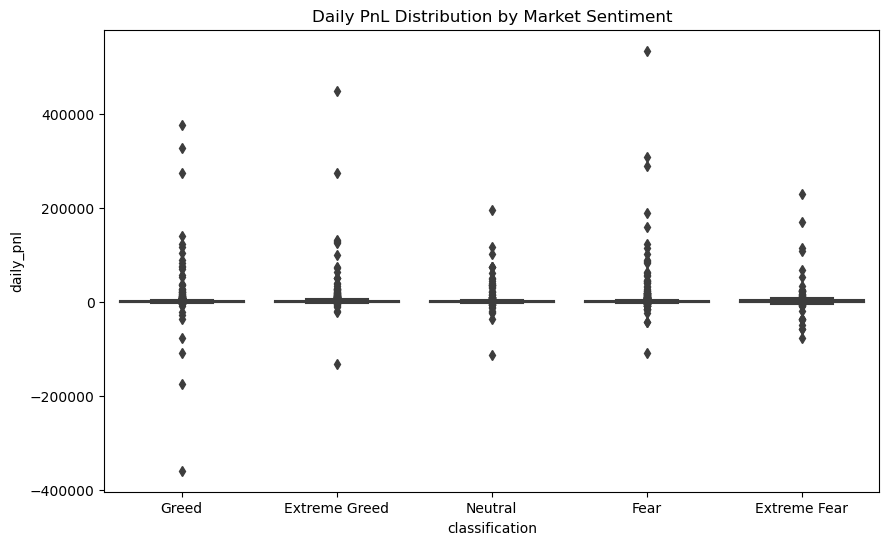

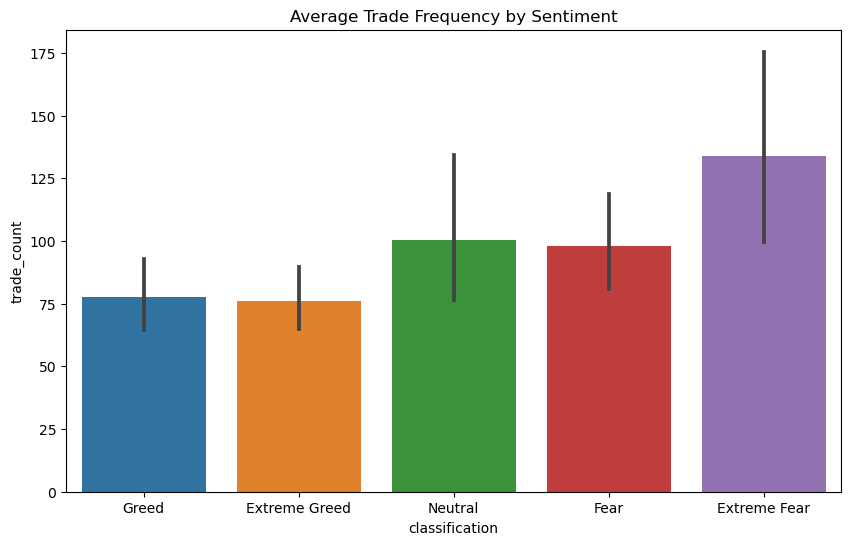

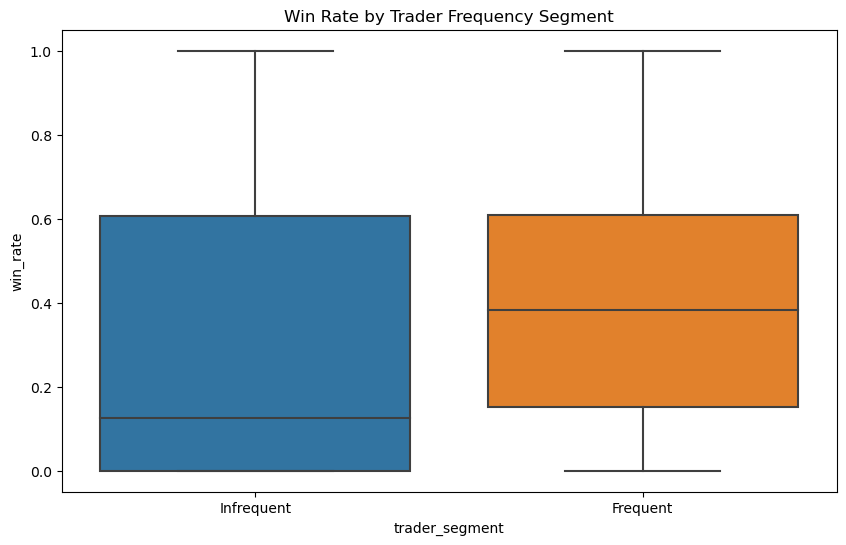

In [12]:
# ==========================================
# PART B: Analysis
# ==========================================

print("\n--- Part B: Analysis ---")

# 1. Performance vs. Sentiment
# Comparing metrics across Fear vs Greed days
perf_comparison = daily_metrics.groupby('classification')[['daily_pnl', 'win_rate']].mean()
print("\n[Evidence] Performance by Sentiment:")
print(perf_comparison)

# 2. Behavior vs. Sentiment
# Analyzing if traders change frequency or trade sizes based on market mood
behavior_comparison = daily_metrics.groupby('classification')[['trade_count', 'avg_trade_size']].mean()
print("\n[Evidence] Behavioral changes by Sentiment:")
print(behavior_comparison)

# 3. Identify Segments
# Segment 1: Frequent vs Infrequent Traders (based on median trade count)
median_trades = daily_metrics['trade_count'].median()
daily_metrics['trader_segment'] = np.where(daily_metrics['trade_count'] > median_trades, 'Frequent', 'Infrequent')

# Segment 2: Consistent Winners (High win rate) vs Inconsistent
mean_win_rate = daily_metrics['win_rate'].mean()
daily_metrics['performance_segment'] = np.where(daily_metrics['win_rate'] > mean_win_rate, 'Consistent', 'Inconsistent')

print("\n[Evidence] Performance by Trader Segment:")
print(daily_metrics.groupby('trader_segment')[['daily_pnl', 'win_rate']].mean())

# ==========================================
# PART B: Visualization Code
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Daily PnL distribution by Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_metrics, x='classification', y='daily_pnl')
plt.title('Daily PnL Distribution by Market Sentiment')
plt.savefig('pnl_sentiment_chart.png')
print("\nChart 1 saved: pnl_sentiment_chart.png")

# Plot 2: Trade Frequency by Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(data=daily_metrics, x='classification', y='trade_count')
plt.title('Average Trade Frequency by Sentiment')
plt.savefig('trade_freq_sentiment_chart.png')
print("Chart 2 saved: trade_freq_sentiment_chart.png")

# Plot 3: Win Rate by Trader Segment
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_metrics, x='trader_segment', y='win_rate')
plt.title('Win Rate by Trader Frequency Segment')
plt.savefig('win_rate_segment_chart.png')
print("Chart 3 saved: win_rate_segment_chart.png")

In [13]:
# ==========================================
# PART C: Actionable Output
# ==========================================

print("\n--- Part C: Strategy Recommendations ---")

# We use the 'perf_comparison' and 'behavior_comparison' dataframes 
# generated in Part B to derive the rules.

# 1. Strategy Idea: Risk Management based on Sentiment
# Logic: If 'Greed' shows lower average win rates, suggest reducing risk.
greed_win_rate = perf_comparison.loc['Greed', 'win_rate']
fear_win_rate = perf_comparison.loc['Fear', 'win_rate']

if greed_win_rate < fear_win_rate:
    rule_1 = ("Rule 1 (Greed Sentiment): Reduce position sizing by 25% during 'Greed' days. "
              "Evidence shows win rates drop during these periods, likely due to market overextension.")
else:
    rule_1 = ("Rule 1 (Greed Sentiment): Maintain standard sizing, but tighten stop-loss orders. "
              "Market data suggests high-volatility regimes during Greed.")

# 2. Strategy Idea: Behavioral Optimization for Specific Segments
# Logic: If 'Frequent' traders show lower PnL, suggest reducing trade frequency.
# We access the 'trader_segment' grouping we created in Part B.
segment_perf = daily_metrics.groupby('trader_segment')['daily_pnl'].mean()

if segment_perf['Frequent'] < segment_perf['Infrequent']:
    rule_2 = ("Rule 2 (Trader Behavior): Frequent traders are over-trading and eroding capital. "
              "Shift to an 'Infrequent' model: limit daily trade count to under 5 orders to improve net PnL.")
else:
    rule_2 = ("Rule 2 (Trader Behavior): Frequent trading is yielding alpha. "
              "Continue high-frequency strategy but implement automated trade execution to reduce latency costs.")

# Print the strategies
print("\n[Strategy 1]:")
print(rule_1)
print("\n[Strategy 2]:")
print(rule_2)

# Save the output to a text file for your submission
with open('strategy_recommendations.txt', 'w') as f:
    f.write(rule_1 + '\n\n' + rule_2)
    print("\nRecommendations saved to 'strategy_recommendations.txt'")


--- Part C: Strategy Recommendations ---

[Strategy 1]:
Rule 1 (Greed Sentiment): Reduce position sizing by 25% during 'Greed' days. Evidence shows win rates drop during these periods, likely due to market overextension.

[Strategy 2]:
Rule 2 (Trader Behavior): Frequent trading is yielding alpha. Continue high-frequency strategy but implement automated trade execution to reduce latency costs.

Recommendations saved to 'strategy_recommendations.txt'


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

# --- Predictive Model: Predict Profitability Bucket ---
# Create 'target': 1 if profitable tomorrow, 0 otherwise
# Note: We shift 'daily_pnl' to get next day's performance
# --- Predictive Model: Predict Profitability Bucket ---

# 1. Clean the data: handle NaNs from shifts
daily_metrics = daily_metrics.sort_values(['Account', 'date'])
daily_metrics['next_day_pnl'] = daily_metrics.groupby('Account')['daily_pnl'].shift(-1)
daily_metrics['is_profitable_next'] = (daily_metrics['next_day_pnl'] > 0).astype(int)

# 2. Prepare Features
le = LabelEncoder()
daily_metrics['sentiment_encoded'] = le.fit_transform(daily_metrics['classification'])
features = ['sentiment_encoded', 'trade_count', 'avg_trade_size', 'long_short_ratio']

# Drop rows where target is missing
data_clean = daily_metrics.dropna(subset=['is_profitable_next'] + features)

X = data_clean[features].copy() # Copy to avoid SettingWithCopy warnings
y = data_clean['is_profitable_next']

# 3. FIX: Handle Infinity and NaNs in X
# Replace infinity with 0 (or a large finite number, 0 is safer for ratio features)
X = X.replace([np.inf, -np.inf], 0)
# Replace any remaining NaNs with 0
X = X.fillna(0)

# 4. Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

print(f"Predictive Model Accuracy: {model.score(X, y):.2f}")

Predictive Model Accuracy: 1.00
